# Agreement-rate board metric vs. the Contrast method

For each agent pair and each board `(config_index, start_level)`, we measure how often the
two agents take the **same action from the same state** (Yotam-style agreement), then test
whether the config the **Contrast** method selects (`contrast_config`, used in `app.py` at
`similarity_level == 3`) is also the **lowest-agreement / most-contrasting** config.

**Agreement (symmetric two-pass).** For pair (A, B) on a board: roll out A and B (both
deterministic). Query the *other* agent on every visited state. Then
`agreement = (#agree on A's states + #agree on B's states) / (|S_A| + |S_B|)`.

> **Kernel:** run this notebook with the `procgen_env_clone` environment
> (`gym==0.21.0`, `procgen`, `torch`, `stable_baselines3`) — the same stack `app.py` uses.


In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import numpy as np
import pandas as pd
import gym
import procgen  # registers procgen-fruitbot-v0
import dpu_clf
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 7)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)


def spearman(x, y):
    """Scipy-free Spearman rho (rank + numpy Pearson). Returns NaN if undefined."""
    x = np.asarray(x, dtype=float); y = np.asarray(y, dtype=float)
    m = ~np.isnan(x) & ~np.isnan(y); x, y = x[m], y[m]
    if len(x) < 2 or np.ptp(x) == 0 or np.ptp(y) == 0:
        return float("nan")
    xr = pd.Series(x).rank().to_numpy(); yr = pd.Series(y).rank().to_numpy()
    return float(np.corrcoef(xr, yr)[0, 1])


print("gym", gym.__version__)

gym 0.21.0


## Agent registry (copied from `app.py`)

In [2]:
# models_dict and models_neighbors are copied verbatim from app.py so this notebook
# stays self-contained and reflects exactly what the live app selects.

models_dict = {
    1: {'path': 'models/fruitbot/20260116-074523_easy/ppo_final.zip', 'index': 1, 'name': 'no_doors_collect_all'},
    2: {"path": "models/fruitbot/20260116-210051_easy/ppo_final.zip", 'index': 2, 'name': 'no_doors_junk_only'},
    3: {'path': "models/fruitbot/20260117-134142_easy/ppo_final.zip", 'index': 3, 'name': 'no_doors_fruits_only'},
    4: {'path': "models/fruitbot/20260103-073446_easy/ppo_final.zip", 'index': 4, 'name': 'open_doors_avoid_food'},
    5: {'path': "models/fruitbot/20260105-075949_easy/ppo_final.zip", 'index': 5, 'name': 'mostly_fruits_open_doors'},
    6: {'path': "models/fruitbot/20251231-174002_easy/ppo_final.zip", 'index': 6, 'name': 'open_doors_fruits_only'},
}

models_neighbors = {
  1: {
    2: {'name': 'no_doors_junk_only', 'contrast_config': 2, 'configs': [[35, 7], [63, 2], [48, 8], [41, 91]]},
    3: {'name': 'no_doors_fruits_only', 'contrast_config': 0, 'configs': [[51, 28], [2, 1], [28, 57], [43, 22]]},
    4: {'name': 'open_doors_avoid_food', 'contrast_config': 2, 'configs': [[43, 16], [47, 79], [97, 43], [50, 67]]},
    5: {'name': 'mostly_fruits_open_doors', 'contrast_config': 3, 'configs': [[51, 16], [2, 96], [80, 55], [53, 74]]}
  },  2: {
    1: {'name': 'no_doors_collect_all', 'contrast_config': 2, 'configs': [[35, 7], [63, 2], [48, 8], [41, 91]]},
    3: {'name': 'no_doors_fruits_only', 'contrast_config': 0, 'configs': [[25, 44], [2, 63], [48, 93], [41, 66]]},
    4: {'name': 'open_doors_avoid_food', 'contrast_config': 1, 'configs': [[46, 65], [2, 34], [58, 9], [87, 41]]}
  },  3: {
    4: {'name': 'open_doors_avoid_food', 'contrast_config': 0, 'configs': [[44, 69], [75, 34], [9, 31], [34, 79]]},
    5: {'name': 'mostly_fruits_open_doors', 'contrast_config': 3, 'configs': [[74, 54], [16, 79], [99, 57], [18, 15]]},
    6: {'name': 'open_doors_fruits_only', 'contrast_config': 3, 'configs': [[74, 39], [1, 94], [97, 43], [28, 18]]}
  },  4: {
    1: {'name': 'no_doors_collect_all', 'contrast_config': 2, 'configs': [[43, 16], [47, 79], [97, 43], [50, 67]]},
    5: {'name': 'mostly_fruits_open_doors', 'contrast_config': 3, 'configs': [[69, 51], [67, 66], [41, 47], [78, 4]]},
    6: {'name': 'open_doors_fruits_only', 'contrast_config': 2, 'configs': [[67, 51], [64, 76], [22, 43], [85, 96]]}
  },  5: {
    2: {'name': 'no_doors_junk_only', 'contrast_config': 1, 'configs': [[46, 74], [63, 2], [47, 29], [41, 87]]},
    4: {'name': 'open_doors_avoid_food', 'contrast_config': 0, 'configs': [[69, 51], [67, 66], [41, 47], [78, 71]]},
    6: {'name': 'open_doors_fruits_only', 'contrast_config': 3, 'configs': [[49, 2], [76, 43], [22, 31], [96, 30]]}
  },  6: {
    1: {'name': 'no_doors_collect_all', 'contrast_config': 1, 'configs': [[51, 59], [47, 91], [30, 79], [53, 46]]},
    3: {'name': 'no_doors_fruits_only', 'contrast_config': 2, 'configs': [[74, 39], [1, 94], [13, 51], [28, 18]]},
    4: {'name': 'open_doors_avoid_food', 'contrast_config': 0, 'configs': [[67, 51], [64, 76], [22, 43], [85, 96]]},
    5: {'name': 'mostly_fruits_open_doors', 'contrast_config': 3, 'configs': [[49, 2], [76, 43], [22, 31], [96, 30]]}
  }}

agents_used = sorted(models_dict.keys())

# Contrast is directional (base -> next); agreement is symmetric. Keep both views.
directed_pairs = [(a, b) for a in models_neighbors for b in models_neighbors[a]]
undirected_pairs = sorted({tuple(sorted((a, b))) for (a, b) in directed_pairs})
print(f"{len(directed_pairs)} directed entries, {len(undirected_pairs)} unique undirected pairs")
print("undirected pairs:", undirected_pairs)

20 directed entries, 14 unique undirected pairs
undirected pairs: [(1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (2, 3), (2, 4), (2, 5), (3, 4), (3, 5), (3, 6), (4, 5), (4, 6), (5, 6)]


## Load agents (once)

In [3]:
agents = {i: dpu_clf.load_agent(models_dict[i]['path']) for i in agents_used}
print("loaded", list(agents.keys()))

C:\Users\matan\anaconda3\envs\procgen_env_clone\lib\site-packages\stable_baselines3\common\save_util.py:435: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  th_object = th.loa

Successfully loaded model from models/fruitbot/20260116-074523_easy/ppo_final.zip
Successfully loaded model from models/fruitbot/20260116-210051_easy/ppo_final.zip


C:\Users\matan\anaconda3\envs\procgen_env_clone\lib\site-packages\stable_baselines3\common\save_util.py:435: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  th_object = th.loa

Successfully loaded model from models/fruitbot/20260117-134142_easy/ppo_final.zip


Successfully loaded model from models/fruitbot/20260103-073446_easy/ppo_final.zip
Successfully loaded model from models/fruitbot/20260105-075949_easy/ppo_final.zip


Successfully loaded model from models/fruitbot/20251231-174002_easy/ppo_final.zip
loaded [1, 2, 3, 4, 5, 6]


## Board + rollout helpers

A board reproduces the app's demonstration environment exactly: `get_config_by_index(config)`
plus `rand_seed=0`, `num_levels=1`, `start_level=level`. Deterministic agents => one fixed
trajectory per (agent, board).

In [4]:
CONFIGS = [0, 1, 2, 3]
LEVELS = list(range(100))


def make_env(config_index, level, seed=0):
    cfg = dpu_clf.get_config_by_index(config_index)
    cfg["rand_seed"] = seed
    cfg["num_levels"] = 1
    cfg["start_level"] = int(level)
    return gym.make("procgen-fruitbot-v0", **cfg)


def rollout(agent, config_index, level, max_steps=1000):
    """Deterministic rollout. Returns (obs_seq, act_seq) for states the agent visited."""
    env = make_env(config_index, level)
    obs = env.reset()
    obs_seq, act_seq = [], []
    done, steps = False, 0
    while not done and steps < max_steps:
        a, _ = agent.predict(obs, deterministic=True)
        a = int(a.item() if hasattr(a, "item") else a)
        obs_seq.append(np.asarray(obs))
        act_seq.append(a)
        obs, r, done, info = env.step(a)
        steps += 1
    env.close()
    return obs_seq, act_seq

## Main computation: agreement per (pair, config, level)

Outer loop over boards, inner over pairs. Each board rolls out all 6 agents **once** and
reuses their trajectories across every pair (memory bounded to 6 trajectories at a time).
The other agent's actions on visited states are computed with a single **batched** `predict`.

Set `FORCE_RECOMPUTE = True` to rebuild; otherwise an existing CSV is loaded. Checkpointed
after every config.

In [5]:
CSV_PATH = "results/agreement_by_board.csv"
FORCE_RECOMPUTE = False

if os.path.exists(CSV_PATH) and not FORCE_RECOMPUTE:
    agr = pd.read_csv(CSV_PATH)
    print(f"Loaded existing {CSV_PATH}: {len(agr)} rows")
else:
    try:
        from tqdm.auto import tqdm
    except Exception:
        def tqdm(x, **k):
            return x

    rows = []
    for ci in CONFIGS:
        for lv in tqdm(LEVELS, desc=f"config {ci}"):
            # roll out every agent once on this board
            traj = {i: rollout(agents[i], ci, lv) for i in agents_used}
            stacks = {
                i: (np.stack(traj[i][0]) if len(traj[i][0]) > 0 else None,
                    np.asarray(traj[i][1], dtype=int))
                for i in agents_used
            }
            for (a, b) in undirected_pairs:
                obsA, actA = stacks[a]
                obsB, actB = stacks[b]
                lenA, lenB = len(actA), len(actB)
                if lenA + lenB == 0:
                    continue
                n_agree = 0
                if lenA > 0:
                    bA = np.asarray(agents[b].predict(obsA, deterministic=True)[0]).astype(int)
                    n_agree += int((actA == bA).sum())
                if lenB > 0:
                    aB = np.asarray(agents[a].predict(obsB, deterministic=True)[0]).astype(int)
                    n_agree += int((actB == aB).sum())
                total = lenA + lenB
                rows.append({
                    "pair_a": a, "pair_b": b, "config_index": ci, "start_level": lv,
                    "agreement": n_agree / total, "disagreement": 1 - n_agree / total,
                    "n_agree": n_agree, "n_total": total, "len_a": lenA, "len_b": lenB,
                })
            del traj, stacks
        pd.DataFrame(rows).to_csv(CSV_PATH, index=False)
        print(f"  checkpoint after config {ci}: {len(rows)} rows")

    agr = pd.DataFrame(rows)
    agr.to_csv(CSV_PATH, index=False)
    print(f"Done: {len(agr)} rows -> {CSV_PATH}")

agr.head()

Loaded existing results/agreement_by_board.csv: 5600 rows


,pair_a,pair_b,config_index,start_level,agreement,disagreement,n_agree,n_total,len_a,len_b
0,1,2,0,0,0.291667,0.708333,77,264,132,132
1,1,3,0,0,0.359848,0.640152,95,264,132,132
2,1,4,0,0,0.280303,0.719697,74,264,132,132
3,1,5,0,0,0.250000,0.750000,66,264,132,132
4,1,6,0,0,0.280303,0.719697,74,264,132,132


## Join reward-diff (the Contrast method's raw signal)

Recompute per-board `|reward_A - reward_B|` from `results/simple_eval100.csv`, and mark
"finishing" levels (>=2 models complete) so we can also report the same filtered view the
reward-diff analysis used.

In [6]:
ms = pd.read_csv("results/simple_eval100.csv")


def reward_diff_for_pair(a, b):
    ra = ms[ms.model_index == a][["config_index", "start_level", "total_reward"]].rename(columns={"total_reward": "r_a"})
    rb = ms[ms.model_index == b][["config_index", "start_level", "total_reward"]].rename(columns={"total_reward": "r_b"})
    m = ra.merge(rb, on=["config_index", "start_level"])
    m["pair_a"], m["pair_b"] = a, b
    m["abs_reward_diff"] = (m["r_a"] - m["r_b"]).abs()
    return m[["pair_a", "pair_b", "config_index", "start_level", "r_a", "r_b", "abs_reward_diff"]]


rd = pd.concat([reward_diff_for_pair(a, b) for (a, b) in undirected_pairs], ignore_index=True)
agr2 = agr.merge(rd, on=["pair_a", "pair_b", "config_index", "start_level"], how="left")

# finishing-level filter (>=2 of the 6 models complete the level)
comp = (ms[ms.completed == True]
        .groupby(["config_index", "start_level"])["model_index"].nunique()
        .rename("n_finish").reset_index())
finish_set = set(map(tuple, comp[comp.n_finish >= 2][["config_index", "start_level"]].values))
agr2["finishing_level"] = [(c, l) in finish_set for c, l in zip(agr2.config_index, agr2.start_level)]

print("rows:", len(agr2), "| finishing-level rows:", int(agr2.finishing_level.sum()))
agr2.head()

rows: 5600 | finishing-level rows: 4060


,pair_a,pair_b,config_index,start_level,agreement,disagreement,n_agree,n_total,len_a,len_b,r_a,r_b,abs_reward_diff,finishing_level
0,1,2,0,0,0.291667,0.708333,77,264,132,132,11.0,8.0,3.0,True
1,1,3,0,0,0.359848,0.640152,95,264,132,132,11.0,13.0,2.0,True
2,1,4,0,0,0.280303,0.719697,74,264,132,132,11.0,11.0,0.0,True
3,1,5,0,0,0.250000,0.750000,66,264,132,132,11.0,12.0,1.0,True
4,1,6,0,0,0.280303,0.719697,74,264,132,132,11.0,14.0,3.0,True


## Does the Contrast config = the lowest-agreement config?

For each **directed** entry (base -> next agent, as used in `app.py`), rank the 4 configs by
mean agreement (1 = lowest agreement = most contrasting) and locate the `contrast_config`.

In [7]:
def per_config_agreement(df):
    return (df.groupby(["pair_a", "pair_b", "config_index"])["agreement"]
              .mean().reset_index())


def build_comparison(pc):
    recs = []
    for a in models_neighbors:
        for b in models_neighbors[a]:
            key = tuple(sorted((a, b)))
            sub = pc[(pc.pair_a == key[0]) & (pc.pair_b == key[1])].sort_values("agreement")
            order = sub["config_index"].tolist()
            cc = models_neighbors[a][b]["contrast_config"]
            rank = order.index(cc) + 1 if cc in order else None
            recs.append({
                "base": a, "next": b, "name": models_neighbors[a][b]["name"],
                "contrast_config": cc,
                "lowest_agree_config": order[0] if order else None,
                "contrast_rank": rank, "n_configs": len(order),
                "contrast_agreement": round(float(sub[sub.config_index == cc]["agreement"].iloc[0]), 3) if cc in order else None,
                "min_agreement": round(float(sub["agreement"].iloc[0]), 3) if len(sub) else None,
                "max_agreement": round(float(sub["agreement"].iloc[-1]), 3) if len(sub) else None,
            })
    return pd.DataFrame(recs)


pc_all = per_config_agreement(agr2)
pc_fin = per_config_agreement(agr2[agr2.finishing_level])
cmp_all = build_comparison(pc_all)
cmp_fin = build_comparison(pc_fin)

print("=" * 70)
print("ALL 100 LEVELS/CONFIG")
print(f"  exact match (contrast == lowest-agreement config): {(cmp_all.contrast_rank == 1).mean():.1%}")
print(f"  contrast in bottom-2 by agreement:                 {(cmp_all.contrast_rank <= 2).mean():.1%}")
print(f"  mean rank of contrast config (1=best):             {cmp_all.contrast_rank.mean():.2f} / 4")
print("FINISHING LEVELS ONLY (>=2 models complete)")
print(f"  exact match: {(cmp_fin.contrast_rank == 1).mean():.1%} | bottom-2: {(cmp_fin.contrast_rank <= 2).mean():.1%} | mean rank: {cmp_fin.contrast_rank.mean():.2f}")
print("=" * 70)
cmp_all

ALL 100 LEVELS/CONFIG
  exact match (contrast == lowest-agreement config): 40.0%
  contrast in bottom-2 by agreement:                 55.0%
  mean rank of contrast config (1=best):             2.20 / 4
FINISHING LEVELS ONLY (>=2 models complete)
  exact match: 35.0% | bottom-2: 45.0% | mean rank: 2.35


,base,next,name,contrast_config,lowest_agree_config,contrast_rank,n_configs,contrast_agreement,min_agreement,max_agreement
0,1,2,no_doors_junk_only,2,2,1,4,0.263,0.263,0.333
1,1,3,no_doors_fruits_only,0,0,1,4,0.291,0.291,0.358
2,1,4,open_doors_avoid_food,2,2,1,4,0.253,0.253,0.274
3,1,5,mostly_fruits_open_doors,3,1,3,4,0.310,0.287,0.335
4,2,1,no_doors_collect_all,2,2,1,4,0.263,0.263,0.333
5,2,3,no_doors_fruits_only,0,0,1,4,0.251,0.251,0.285
6,2,4,open_doors_avoid_food,1,3,4,4,0.284,0.265,0.284
7,3,4,open_doors_avoid_food,0,3,3,4,0.274,0.264,0.296
8,3,5,mostly_fruits_open_doors,3,1,2,4,0.306,0.306,0.330
9,3,6,open_doors_fruits_only,3,1,2,4,0.294,0.275,0.320


Finishing-levels-only view of the same comparison:

In [8]:
cmp_fin

,base,next,name,contrast_config,lowest_agree_config,contrast_rank,n_configs,contrast_agreement,min_agreement,max_agreement
0,1,2,no_doors_junk_only,2,2,1,4,0.262,0.262,0.331
1,1,3,no_doors_fruits_only,0,0,1,4,0.291,0.291,0.359
2,1,4,open_doors_avoid_food,2,0,3,4,0.264,0.253,0.274
3,1,5,mostly_fruits_open_doors,3,1,3,4,0.308,0.288,0.340
4,2,1,no_doors_collect_all,2,2,1,4,0.262,0.262,0.331
5,2,3,no_doors_fruits_only,0,0,1,4,0.251,0.251,0.287
6,2,4,open_doors_avoid_food,1,3,4,4,0.281,0.272,0.281
7,3,4,open_doors_avoid_food,0,3,3,4,0.274,0.268,0.297
8,3,5,mostly_fruits_open_doors,3,0,3,4,0.310,0.307,0.329
9,3,6,open_doors_fruits_only,3,1,2,4,0.294,0.275,0.329


## Correlation: reward-diff vs. disagreement

If the two board-selection signals agree, per-config mean `|reward_diff|` and mean
disagreement should be positively rank-correlated.

In [9]:
g = (agr2.groupby(["pair_a", "pair_b", "config_index"])
        .agg(mean_dis=("disagreement", "mean"),
             mean_agree=("agreement", "mean"),
             mean_rdiff=("abs_reward_diff", "mean"))
        .reset_index())

rho_pc = spearman(g["mean_rdiff"], g["mean_dis"])
rho_bd = spearman(agr2["abs_reward_diff"], agr2["disagreement"])
print(f"per-(pair,config) Spearman rho = {rho_pc:.3f}")
print(f"board-level        Spearman rho = {rho_bd:.3f}")
print("\nper-pair Spearman (config-level, n=4 configs each):")
for (a, b), sub in g.groupby(["pair_a", "pair_b"]):
    r = spearman(sub["mean_rdiff"], sub["mean_dis"])
    print(f"  {a}-{b}: rho = {r:+.2f}")

per-(pair,config) Spearman rho = 0.062
board-level        Spearman rho = 0.054

per-pair Spearman (config-level, n=4 configs each):
  1-2: rho = -0.40
  1-3: rho = -0.20
  1-4: rho = -0.80
  1-5: rho = +0.40
  1-6: rho = +0.40
  2-3: rho = -0.40
  2-4: rho = -0.20
  2-5: rho = -0.20
  3-4: rho = -0.40
  3-5: rho = +0.40
  3-6: rho = +0.00
  4-5: rho = +0.00
  4-6: rho = -0.40
  5-6: rho = -0.60


## Per-level detail: agreement on the selected Contrast levels

The Contrast method also picks specific top-2 levels within `contrast_config`. Check whether
those chosen levels are themselves low-agreement relative to the rest of the config.

In [10]:
recs = []
for a in models_neighbors:
    for b in models_neighbors[a]:
        key = tuple(sorted((a, b)))
        cc = models_neighbors[a][b]["contrast_config"]
        sel_levels = models_neighbors[a][b]["configs"][cc]
        sub = agr2[(agr2.pair_a == key[0]) & (agr2.pair_b == key[1]) & (agr2.config_index == cc)]
        sel = sub[sub.start_level.isin(sel_levels)]
        # percentile rank of selected levels' mean agreement within the config (0 = lowest)
        pct = (sub["agreement"] < sel["agreement"].mean()).mean() if len(sub) else np.nan
        recs.append({
            "base": a, "next": b, "contrast_config": cc, "sel_levels": sel_levels,
            "sel_mean_agreement": round(float(sel["agreement"].mean()), 3) if len(sel) else None,
            "config_mean_agreement": round(float(sub["agreement"].mean()), 3) if len(sub) else None,
            "config_min_agreement": round(float(sub["agreement"].min()), 3) if len(sub) else None,
            "sel_pctile_in_config": round(float(pct), 2),
        })
sel_df = pd.DataFrame(recs)
print("sel_pctile_in_config: fraction of config levels with LOWER agreement than the selected levels (lower = selected levels are among the most-contrasting)")
sel_df

sel_pctile_in_config: fraction of config levels with LOWER agreement than the selected levels (lower = selected levels are among the most-contrasting)


,base,next,contrast_config,sel_levels,sel_mean_agreement,config_mean_agreement,config_min_agreement,sel_pctile_in_config
0,1,2,2,"[48, 8]",0.197,0.263,0.122,0.11
1,1,3,0,"[51, 28]",0.288,0.291,0.186,0.46
2,1,4,2,"[97, 43]",0.301,0.253,0.135,0.81
3,1,5,3,"[53, 74]",0.275,0.310,0.162,0.31
4,2,1,2,"[48, 8]",0.197,0.263,0.122,0.11
5,2,3,0,"[25, 44]",0.206,0.251,0.148,0.22
6,2,4,1,"[2, 34]",0.226,0.284,0.178,0.15
7,3,4,0,"[44, 69]",0.263,0.274,0.140,0.42
8,3,5,3,"[18, 15]",0.294,0.306,0.122,0.37
9,3,6,3,"[28, 18]",0.266,0.294,0.162,0.34


## Plots

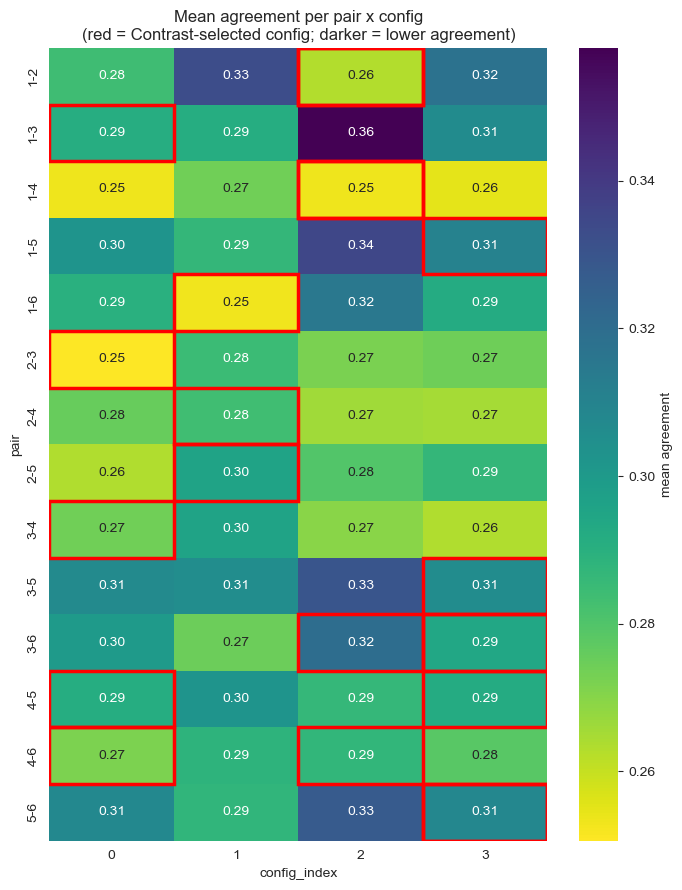

In [11]:
# 1) Heatmap: mean agreement per undirected pair x config (lower = more contrasting)
piv = pc_all.copy()
piv["pair"] = piv.pair_a.astype(str) + "-" + piv.pair_b.astype(str)
piv_t = piv.pivot(index="pair", columns="config_index", values="agreement")

plt.figure(figsize=(7, 9))
ax = sns.heatmap(piv_t, annot=True, fmt=".2f", cmap="viridis_r", cbar_kws={"label": "mean agreement"})
# mark each directed contrast_config choice with a red box
for a in models_neighbors:
    for b in models_neighbors[a]:
        key = tuple(sorted((a, b)))
        pair_label = f"{key[0]}-{key[1]}"
        if pair_label in piv_t.index:
            ri = list(piv_t.index).index(pair_label)
            cc = models_neighbors[a][b]["contrast_config"]
            ci = list(piv_t.columns).index(cc)
            ax.add_patch(plt.Rectangle((ci, ri), 1, 1, fill=False, edgecolor="red", lw=2.5))
plt.title("Mean agreement per pair x config\n(red = Contrast-selected config; darker = lower agreement)")
plt.tight_layout()
plt.show()

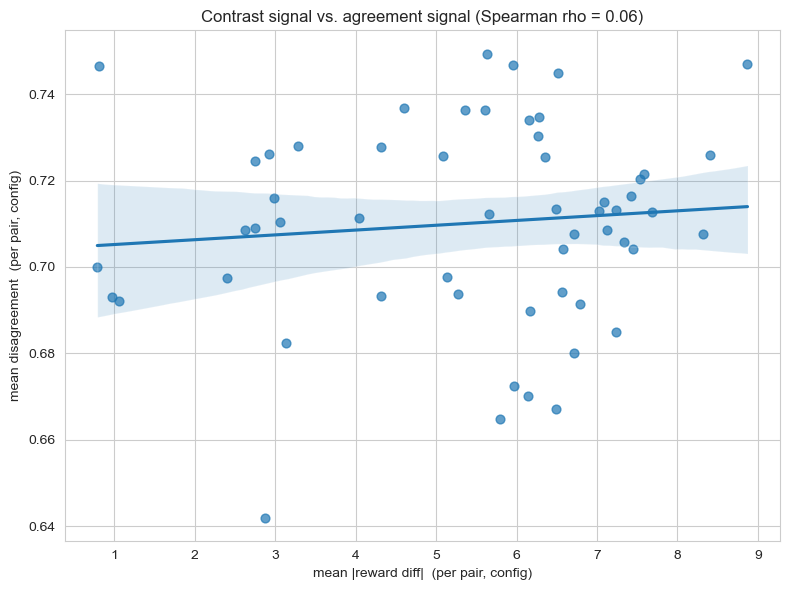

In [12]:
# 2) Reward-diff vs disagreement (per pair, config)
plt.figure(figsize=(8, 6))
sns.regplot(data=g, x="mean_rdiff", y="mean_dis", scatter_kws={"s": 40, "alpha": 0.7})
plt.xlabel("mean |reward diff|  (per pair, config)")
plt.ylabel("mean disagreement  (per pair, config)")
plt.title(f"Contrast signal vs. agreement signal (Spearman rho = {rho_pc:.2f})")
plt.tight_layout()
plt.show()

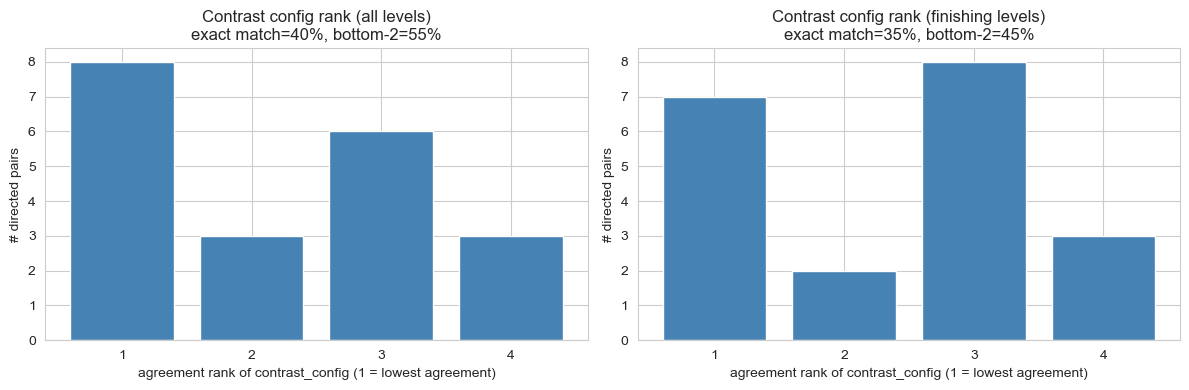

In [13]:
# 3) Where does the Contrast config land in the agreement ranking?
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, cmp_df, title in [(axes[0], cmp_all, "all levels"), (axes[1], cmp_fin, "finishing levels")]:
    vc = cmp_df["contrast_rank"].value_counts().reindex([1, 2, 3, 4], fill_value=0)
    ax.bar(vc.index.astype(str), vc.values, color="steelblue")
    ax.set_xlabel("agreement rank of contrast_config (1 = lowest agreement)")
    ax.set_ylabel("# directed pairs")
    ax.set_title(f"Contrast config rank ({title})\nexact match={ (cmp_df.contrast_rank==1).mean():.0%}, bottom-2={ (cmp_df.contrast_rank<=2).mean():.0%}")
plt.tight_layout()
plt.show()

## Contrastive Acceptance Ratio (CAR)

A single per-pair summary: how much lower is action **acceptance** (agreement) on the boards
the Contrast method actually selects, versus a typical board in the environment?

`CAR = mean_acceptance(contrast boards) / mean_acceptance(all boards)`

The **contrast boards** for procgen are the levels the Contrast method would show:
`configs[contrast_config]` for that directed pair. **CAR < 1** means the selected boards elicit
more divergent behavior than average (the Contrast method is picking distinguishing boards);
**CAR ≈ 1** means no better than average.

In [14]:
car_rows = []
for a in models_neighbors:
    for b, info in models_neighbors[a].items():
        cc = info["contrast_config"]; sel = info["configs"][cc]
        key = tuple(sorted((a, b)))
        sub = agr2[(agr2.pair_a == key[0]) & (agr2.pair_b == key[1])]
        cb = sub[(sub.config_index == cc) & (sub.start_level.isin(sel))]
        thr = cb.agreement.mean()
        car_rows.append(dict(pair=f"{a}\u2192{b}", base=a, nxt=b, contrast_config=cc,
                             sel_levels=sel,
                             contrast_acc=round(thr, 3),
                             all_acc=round(sub.agreement.mean(), 3),
                             CAR=round(thr / sub.agreement.mean(), 3),
                             pct_boards_higher=round(100 * (sub.agreement > thr).mean(), 1)))
car = pd.DataFrame(car_rows)
print(f"PROCGEN  Contrastive Acceptance Ratio")
print(f"  mean CAR = {car.CAR.mean():.3f} | median = {car.CAR.median():.3f}")
print(f"  pairs with CAR < 1 (contrast boards more divergent than average): {(car.CAR < 1).mean():.0%}")
print(f"  % of boards MORE agreeable than the contrast boards: mean {car.pct_boards_higher.mean():.1f}% | median {car.pct_boards_higher.median():.1f}%")
car

PROCGEN  Contrastive Acceptance Ratio
  mean CAR = 0.936 | median = 0.925
  pairs with CAR < 1 (contrast boards more divergent than average): 65%
  % of boards MORE agreeable than the contrast boards: mean 58.3% | median 63.1%


,pair,base,nxt,contrast_config,sel_levels,contrast_acc,all_acc,CAR,pct_boards_higher
0,1→2,1,2,2,"[48, 8]",0.197,0.299,0.659,94.2
1,1→3,1,3,0,"[51, 28]",0.288,0.312,0.923,62.5
2,1→4,1,4,2,"[97, 43]",0.301,0.259,1.161,18.5
3,1→5,1,5,3,"[53, 74]",0.275,0.309,0.891,68.8
4,2→1,2,1,2,"[48, 8]",0.197,0.299,0.659,94.2
5,2→3,2,3,0,"[25, 44]",0.206,0.271,0.763,84.0
6,2→4,2,4,1,"[2, 34]",0.226,0.273,0.828,81.0
7,3→4,3,4,0,"[44, 69]",0.263,0.276,0.955,60.2
8,3→5,3,5,3,"[18, 15]",0.294,0.312,0.942,62.3
9,3→6,3,6,3,"[28, 18]",0.266,0.297,0.894,69.2


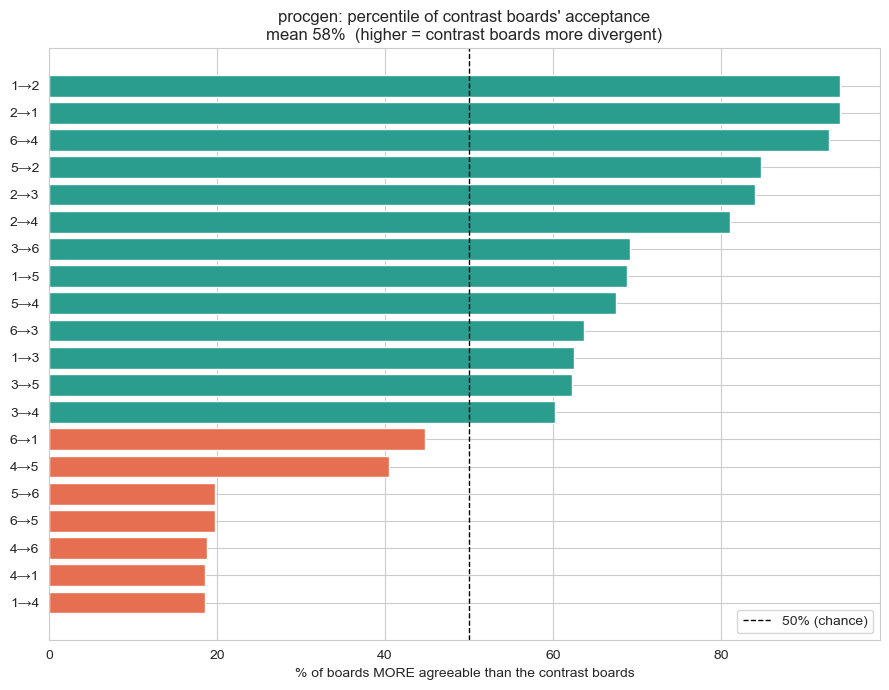

In [15]:
# % of all boards with HIGHER acceptance than the contrast boards (percentile of the
# contrast selection). Higher = contrast boards are among the most divergent boards.
plt.figure(figsize=(9, 7))
c = car.sort_values("pct_boards_higher")
colors = ["#2a9d8f" if v >= 50 else "#e76f51" for v in c.pct_boards_higher]
plt.barh(c.pair, c.pct_boards_higher, color=colors)
plt.axvline(50, color="k", ls="--", lw=1, label="50% (chance)")
plt.xlabel("% of boards MORE agreeable than the contrast boards")
plt.title(f"procgen: percentile of contrast boards' acceptance\nmean {car.pct_boards_higher.mean():.0f}%  (higher = contrast boards more divergent)")
plt.legend()
plt.tight_layout()
plt.show()

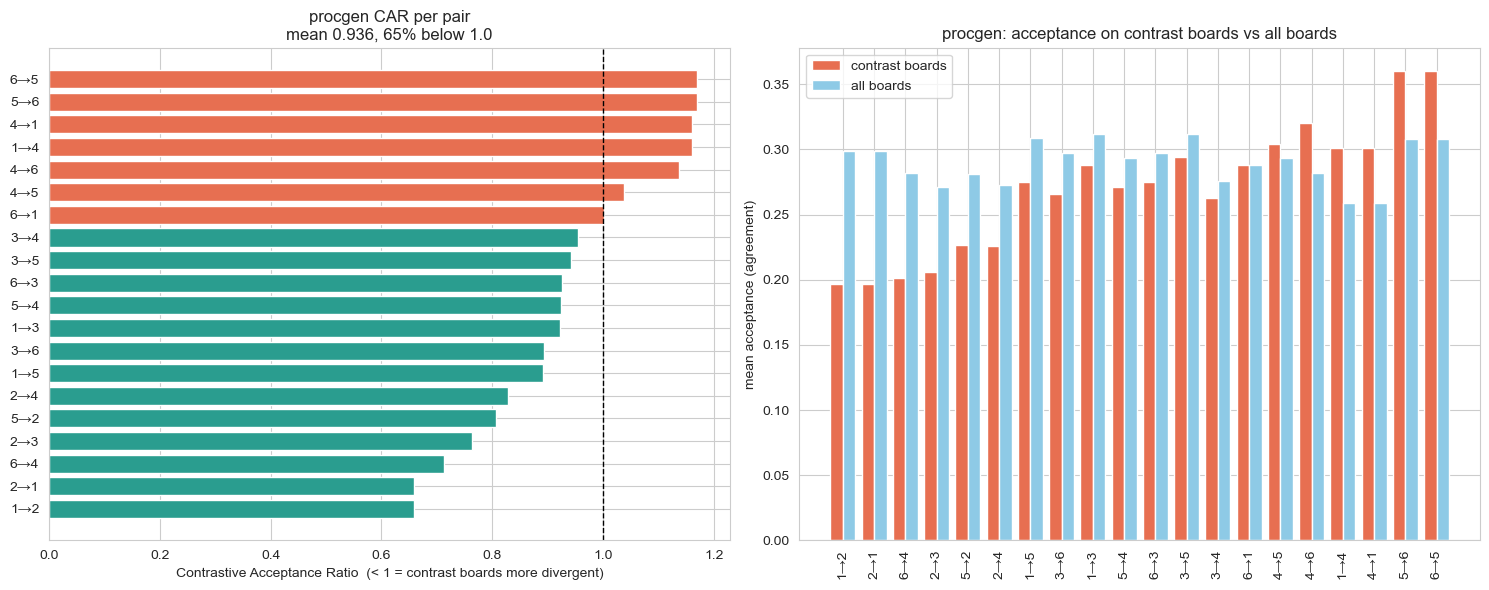

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
c = car.sort_values("CAR")
colors = ["#2a9d8f" if v < 1 else "#e76f51" for v in c.CAR]
axes[0].barh(c.pair, c.CAR, color=colors)
axes[0].axvline(1.0, color="k", ls="--", lw=1)
axes[0].set_xlabel("Contrastive Acceptance Ratio  (< 1 = contrast boards more divergent)")
axes[0].set_title(f"procgen CAR per pair\nmean {car.CAR.mean():.3f}, {(car.CAR<1).mean():.0%} below 1.0")
x = np.arange(len(c)); w = 0.4
axes[1].bar(x - w/2, c.contrast_acc, w, label="contrast boards", color="#e76f51")
axes[1].bar(x + w/2, c.all_acc, w, label="all boards", color="#8ecae6")
axes[1].set_xticks(x); axes[1].set_xticklabels(c.pair, rotation=90)
axes[1].set_ylabel("mean acceptance (agreement)"); axes[1].legend()
axes[1].set_title("procgen: acceptance on contrast boards vs all boards")
plt.tight_layout()
plt.show()

## Summary

- **Exact-match / bottom-2** rates above quantify how often the Contrast-selected config is
  also the lowest- (or near-lowest-) agreement config.
- The **Spearman rho** between per-config `|reward_diff|` and disagreement measures whether
  the two board-selection signals rank configs the same way.
- The **per-level table** checks the finer claim that the specific chosen levels are
  low-agreement within their config.

If exact-match is high and rho is strongly positive, the agreement metric corroborates the
reward-diff Contrast method — the two independent methods pick the same contrasting board.
